# Analysis Notebook

This Notebook is a proof of concept to show a simple analysis of the Network states learned in Notebook `01_poc_training.ipynb`

## Phase 2: From Neural Dynamics to Information Theory

Classical Shannon entropy (and by extension, PID and $\Phi$ ID) was designed for discrete symbols, not the continuous floating-point matrices generated by neural networks. This notebook builds the data pipeline to bridge that gap.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

### 1. Loading the Dynamics

**What:** Importing the frozen $h_t$ states from our trained Vanilla model.

**Why:** Information decomposition is performed *after* training. We analyze the network's settled strategy, treating the weights as static and looking only at the state activations over time.

In [2]:
# 1. Load the data generated by the training notebook
try:
    hidden_states = np.load("poc_hidden_states.npy", allow_pickle=True).item()
    print("Successfully loaded network dynamics.")
except FileNotFoundError:
    print("Run notebook 01 first to generate data!")

vanilla_data = hidden_states["vanilla"] # Shape: (50 timesteps, 80 neurons)

Successfully loaded network dynamics.


### 2. Dimensionality Reduction (TDR Proxy)

**What:** Using PCA to crush the 80-neuron space down to 2 axes. 

**Why:** This is the most crucial step. If we discretize 80 neurons into 4 bins each, the network has $4^{80}$ possible states. Our probability tables would be entirely zeros (the "curse of dimensionality"). By projecting the data into a low-dimensional space (mimicking Mante's Targeted Dimensionality Reduction), we isolate the functional components of the network and make the PID math tractable.

In [3]:
# 2. Dimensionality Reduction (Proxy for Mante's TDR)
# We want to reduce 80 neurons down to 2 functional macro-components
pca = PCA(n_components=2)
reduced_states = pca.fit_transform(vanilla_data) # Shape: (50, 2)

print(f"Variance explained by top 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained by top 2 components: 97.2%


### 3. Discretization Pipeline

**What:** Converting continuous coordinate values into discrete bins (e.g., States 0, 1, 2, 3).

**Why:** Standard PID libraries (`phyid`, `JIDT`) require discrete input variables to calculate mutual information and synergy. We digitize the principal components to map the continuous trajectory into a finite alphabet of states.

In [4]:
# 3. Discretization Pipeline (Continuous to Discrete)
# We will chop each continuous component into 4 distinct bins/states
num_bins = 4
discrete_states = np.zeros_like(reduced_states, dtype=int)

for i in range(2): # For PC1 and PC2
    component_data = reduced_states[:, i]
    # Define bin edges evenly between the min and max values
    bins = np.linspace(component_data.min(), component_data.max(), num_bins + 1)
    # Digitize converts continuous values to bin indices (1 to 4)
    # We subtract 1 so indices are 0 to 3
    discrete_states[:, i] = np.digitize(component_data, bins) - 1

# Ensure bounds just in case
discrete_states = np.clip(discrete_states, 0, num_bins - 1)

### 4. Building the Probability Landscape

**What:** Counting the frequency of joint states to build a Probability Mass Function (PMF).

**Why:** Synergy is calculated based on how often different variables overlap. This matrix tells us exactly how the two principal components co-occur across the trial. This 2D array is the final artifact we will hand off to the heavy mathematical libraries to compute the actual Redundancy/Synergy split.

In [5]:
# 4. Building the Probability Landscape (The basis for PID)
# Count how often the network visits each joint state (PC1_state, PC2_state)
joint_probabilities = np.zeros((num_bins, num_bins))

for t in range(len(discrete_states)):
    state_c1 = discrete_states[t, 0]
    state_c2 = discrete_states[t, 1]
    joint_probabilities[state_c1, state_c2] += 1

# Normalize to sum to 1.0
joint_probabilities /= joint_probabilities.sum()

### Plotting

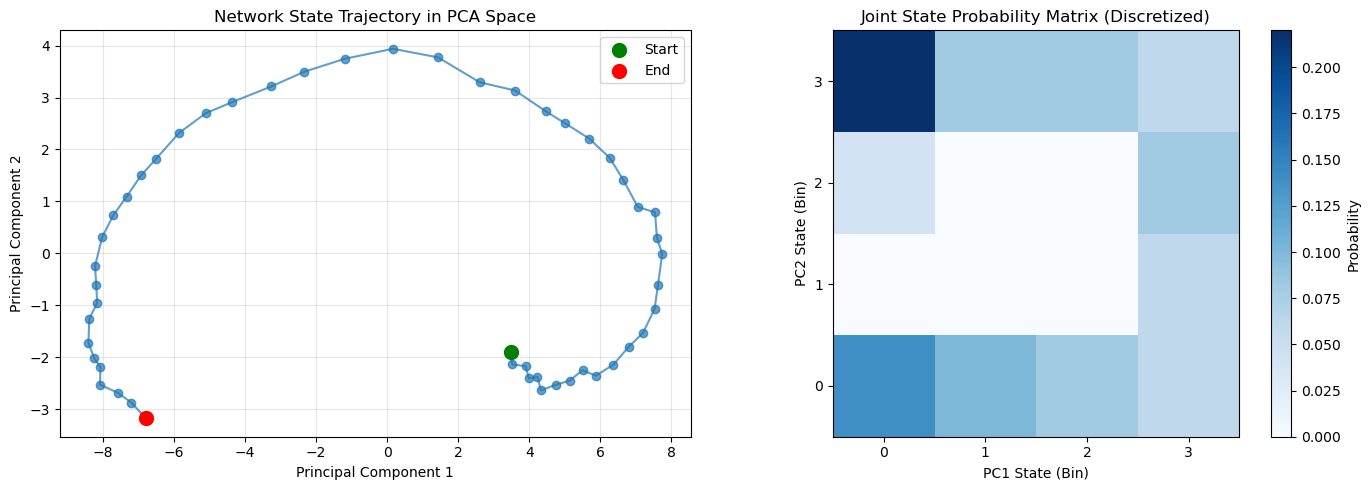

This joint probability matrix is exactly what will be fed into the JIDT or phyid libraries to compute PID.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 2D Trajectory of the Network
axes[0].plot(reduced_states[:, 0], reduced_states[:, 1], '-o', alpha=0.7)
axes[0].set_title("Network State Trajectory in PCA Space")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].grid(True, alpha=0.3)
# Mark start and end points
axes[0].scatter(reduced_states[0, 0], reduced_states[0, 1], c='green', s=100, label='Start', zorder=5)
axes[0].scatter(reduced_states[-1, 0], reduced_states[-1, 1], c='red', s=100, label='End', zorder=5)
axes[0].legend()

# Plot 2: The Joint Probability Matrix (Discrete State Space)
im = axes[1].imshow(joint_probabilities, cmap='Blues', origin='lower')
axes[1].set_title("Joint State Probability Matrix (Discretized)")
axes[1].set_xlabel("PC1 State (Bin)")
axes[1].set_ylabel("PC2 State (Bin)")
axes[1].set_xticks(range(num_bins))
axes[1].set_yticks(range(num_bins))
plt.colorbar(im, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()

print("This joint probability matrix is exactly what will be fed into the JIDT or phyid libraries to compute PID.")